In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Live_Query_Engine_Test") \
    .master("local[2]") \
    .config("spark.jars.packages",
            "org.apache.iceberg:iceberg-spark-runtime-4.0_2.13:1.10.1,"
            "org.apache.hadoop:hadoop-aws:3.4.1,"
            "software.amazon.awssdk:bundle:2.29.38") \
    .config("spark.sql.extensions",
            "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions") \
    .config("spark.sql.catalog.local",           "org.apache.iceberg.spark.SparkCatalog") \
    .config("spark.sql.catalog.local.type",      "rest") \
    .config("spark.sql.catalog.local.uri",       "http://rest-catalog:8181") \
    .config("spark.sql.catalog.local.warehouse", "s3a://business-data/") \
    .config("spark.sql.catalog.local.s3.endpoint",          "http://minio:9000") \
    .config("spark.sql.catalog.local.s3.path-style-access", "true") \
    .config("spark.sql.catalog.local.s3.region",            "us-east-1") \
    .config("spark.hadoop.fs.s3a.endpoint",          "http://minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key",        "admin") \
    .config("spark.hadoop.fs.s3a.secret.key",        "password") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

print(f"Spark Session Ready! Version: {spark.version}")

Spark Session Ready! Version: 4.0.2


In [2]:
# Query the live Iceberg table
spark.sql("""
    SELECT 
        traffic_event_ts, 
        traffic_borough, 
        traffic_speed, 
        aq_pm25_ugm3, 
        weather_temperature
    FROM local.db.enriched_traffic
    ORDER BY traffic_event_ts DESC
    LIMIT 10
""").show(truncate=False)

+-------------------+---------------+-------------+------------+-------------------+
|traffic_event_ts   |traffic_borough|traffic_speed|aq_pm25_ugm3|weather_temperature|
+-------------------+---------------+-------------+------------+-------------------+
|2026-05-08 19:13:13|Queens         |6.83         |7.6         |62                 |
|2026-05-08 19:13:13|Queens         |6.83         |7.6         |61                 |
|2026-05-08 19:13:13|Queens         |6.83         |7.6         |63                 |
|2026-05-08 19:13:13|Queens         |6.83         |7.6         |61                 |
|2026-05-08 19:13:13|Queens         |6.83         |7.6         |61                 |
|2026-05-08 19:13:13|Queens         |6.83         |7.6         |62                 |
|2026-05-08 19:13:13|Queens         |6.83         |7.6         |61                 |
|2026-05-08 19:13:13|Queens         |6.83         |7.6         |63                 |
|2026-05-08 19:13:13|Queens         |6.83         |7.6         |6

In [3]:
# Verify the aggregations and non-null air quality readings
spark.sql("""
    SELECT 
        traffic_borough, 
        COUNT(*) as total_records,
        ROUND(AVG(traffic_speed), 2) as avg_speed_mph, 
        ROUND(AVG(aq_pm25_ugm3), 2) as avg_pm25,
        MAX(weather_temperature) as max_temp
    FROM local.db.enriched_traffic
    GROUP BY traffic_borough
    ORDER BY avg_speed_mph ASC
""").show(truncate=False)

+---------------+-------------+-------------+--------+--------+
|traffic_borough|total_records|avg_speed_mph|avg_pm25|max_temp|
+---------------+-------------+-------------+--------+--------+
|Manhattan      |7152775      |13.36        |6.12    |83      |
|Bronx          |3294320      |22.24        |4.61    |83      |
|Brooklyn       |2061979      |26.49        |7.5     |83      |
|Queens         |2181451      |32.58        |9.5     |83      |
|Staten Island  |768087       |34.6         |7.99    |83      |
+---------------+-------------+-------------+--------+--------+



In [4]:
# 1. Read the raw Parquet dumps directly from MinIO
raw_traffic = spark.read.parquet("s3a://raw-data/traffic/")
raw_traffic.createOrReplaceTempView("raw_traffic_view")

# 2. See how many records have successfully landed
spark.sql("""
    SELECT borough, COUNT(*) as rows_ingested 
    FROM raw_traffic_view 
    GROUP BY borough
""").show()

+-------------+-------------+
|      borough|rows_ingested|
+-------------+-------------+
|       Queens|        22066|
|     Brooklyn|         7147|
|Staten Island|        16483|
|    Manhattan|        15944|
|        Bronx|        15058|
+-------------+-------------+



In [5]:
# Borough-level diagnostics: traffic-only vs traffic+AQ vs traffic+AQ+weather
spark.sql("""
WITH traffic_only AS (
  SELECT borough AS traffic_borough, COUNT(*) AS traffic_rows
  FROM parquet.`s3a://raw-data/traffic/`
  WHERE borough IS NOT NULL
  GROUP BY borough
),
aq_joined AS (
  SELECT traffic_borough, COUNT(*) AS traffic_aq_rows
  FROM local.db.enriched_traffic
  GROUP BY traffic_borough
),
aq_weather_joined AS (
  SELECT traffic_borough, COUNT(*) AS traffic_aq_weather_rows
  FROM local.db.enriched_traffic
  WHERE weather_temperature IS NOT NULL
  GROUP BY traffic_borough
)
SELECT
  t.traffic_borough,
  t.traffic_rows,
  COALESCE(a.traffic_aq_rows, 0) AS traffic_aq_rows,
  COALESCE(w.traffic_aq_weather_rows, 0) AS traffic_aq_weather_rows,
  ROUND(100.0 * COALESCE(a.traffic_aq_rows, 0) / t.traffic_rows, 2) AS aq_match_pct,
  ROUND(100.0 * COALESCE(w.traffic_aq_weather_rows, 0) / t.traffic_rows, 2) AS aq_weather_match_pct
FROM traffic_only t
LEFT JOIN aq_joined a ON t.traffic_borough = a.traffic_borough
LEFT JOIN aq_weather_joined w ON t.traffic_borough = w.traffic_borough
ORDER BY t.traffic_rows DESC
""").show(truncate=False)

+---------------+------------+---------------+-----------------------+------------+--------------------+
|traffic_borough|traffic_rows|traffic_aq_rows|traffic_aq_weather_rows|aq_match_pct|aq_weather_match_pct|
+---------------+------------+---------------+-----------------------+------------+--------------------+
|Queens         |22066       |2181451        |2173538                |9886.03     |9850.17             |
|Staten Island  |16483       |768087         |762239                 |4659.87     |4624.39             |
|Manhattan      |15944       |7152775        |7145894                |44861.86    |44818.70            |
|Bronx          |15058       |3294320        |3288545                |21877.54    |21839.19            |
|Brooklyn       |7147        |2061979        |2059369                |28850.97    |28814.45            |
+---------------+------------+---------------+-----------------------+------------+--------------------+



In [6]:
spark.read.parquet("s3a://raw-data/weather/").selectExpr(
    "MIN(kafka_timestamp) as oldest", "MAX(kafka_timestamp) as newest"
).show(truncate=False)

spark.read.parquet("s3a://raw-data/openaq/").selectExpr(
    "MIN(kafka_timestamp) as oldest", "MAX(kafka_timestamp) as newest"
).show(truncate=False)

+-----------------------+-----------------------+
|oldest                 |newest                 |
+-----------------------+-----------------------+
|2026-05-03 17:07:54.674|2026-05-08 20:03:41.428|
+-----------------------+-----------------------+

+-----------------------+-----------------------+
|oldest                 |newest                 |
+-----------------------+-----------------------+
|2026-05-01 16:18:19.567|2026-05-08 20:04:07.913|
+-----------------------+-----------------------+



In [7]:
spark.sql("""
    SELECT MIN(traffic_event_ts), MAX(traffic_event_ts), COUNT(*) as total
    FROM local.db.enriched_traffic
""").show(truncate=False)

+---------------------+---------------------+--------+
|min(traffic_event_ts)|max(traffic_event_ts)|total   |
+---------------------+---------------------+--------+
|2026-05-01 14:38:00  |2026-05-08 19:13:13  |15458612|
+---------------------+---------------------+--------+



In [8]:
spark.sql("""
    SELECT 
        MAX(traffic_event_ts) as latest_traffic,
        (SELECT MIN(kafka_timestamp) FROM parquet.`s3a://raw-data/openaq/`) as earliest_aq
    FROM local.db.enriched_traffic
""").show(truncate=False)

+-------------------+-----------------------+
|latest_traffic     |earliest_aq            |
+-------------------+-----------------------+
|2026-05-08 19:13:13|2026-05-01 16:18:19.567|
+-------------------+-----------------------+



In [9]:
spark.sql("""
    SELECT 
        traffic_borough,
        traffic_id,
        COUNT(*) as aq_matches_per_traffic_row
    FROM local.db.enriched_traffic
    GROUP BY traffic_borough, traffic_id
    ORDER BY aq_matches_per_traffic_row DESC
    LIMIT 20
""").show(truncate=False)

+---------------+----------+--------------------------+
|traffic_borough|traffic_id|aq_matches_per_traffic_row|
+---------------+----------+--------------------------+
|Manhattan      |445       |873329                    |
|Brooklyn       |148       |605920                    |
|Brooklyn       |157       |605920                    |
|Manhattan      |149       |605918                    |
|Manhattan      |106       |605918                    |
|Brooklyn       |154       |605605                    |
|Manhattan      |448       |602883                    |
|Manhattan      |221       |505801                    |
|Manhattan      |215       |505801                    |
|Manhattan      |124       |483162                    |
|Manhattan      |217       |404695                    |
|Manhattan      |223       |404695                    |
|Manhattan      |145       |404695                    |
|Manhattan      |150       |404695                    |
|Manhattan      |364       |402670              

In [10]:
spark.sql("""
    SELECT 
        h3_index,
        COUNT(*) as rows
    FROM local.db.enriched_traffic
    GROUP BY h3_index
    ORDER BY rows DESC
    LIMIT 10
""").show(truncate=False)

+---------------+-------+
|h3_index       |rows   |
+---------------+-------+
|872a10729ffffff|2906525|
|872a100aeffffff|2726391|
|872a1072dffffff|1618780|
|872a100d2ffffff|1414272|
|872a1008bffffff|1208801|
|872a1072cffffff|873329 |
|872a100f2ffffff|805226 |
|872a10623ffffff|608262 |
|872a1001effffff|404880 |
|872a10013ffffff|404320 |
+---------------+-------+



In [11]:
spark.sql("""
SELECT
  MIN(traffic_event_ts) AS min_traffic,
  MAX(traffic_event_ts) AS max_traffic,
  MIN(aq_event_ts) AS min_aq,
  MAX(aq_event_ts) AS max_aq,
  MIN(weather_event_ts) AS min_weather,
  MAX(weather_event_ts) AS max_weather
FROM local.db.enriched_traffic
""").show(truncate=False)

spark.sql("""
SELECT
  COUNT(*) AS total_rows,
  SUM(CASE WHEN aq_pm25_ugm3 IS NOT NULL THEN 1 ELSE 0 END) AS aq_rows,
  SUM(CASE WHEN weather_temperature IS NOT NULL THEN 1 ELSE 0 END) AS weather_rows
FROM local.db.enriched_traffic
""").show(truncate=False)

+-------------------+-------------------+-----------------------+-------------------+-------------------+-------------------+
|min_traffic        |max_traffic        |min_aq                 |max_aq             |min_weather        |max_weather        |
+-------------------+-------------------+-----------------------+-------------------+-------------------+-------------------+
|2026-05-01 14:38:00|2026-05-08 19:13:13|2026-05-01 16:18:19.194|2026-05-08 19:26:17|2026-05-03 17:14:18|2026-05-08 19:27:01|
+-------------------+-------------------+-----------------------+-------------------+-------------------+-------------------+

+----------+--------+------------+
|total_rows|aq_rows |weather_rows|
+----------+--------+------------+
|15458612  |14937335|15429585    |
+----------+--------+------------+



In [12]:
# AQ Debugging

spark.sql("""
SELECT
  COUNT(*) AS total_rows,
  SUM(CASE WHEN aq_pm25_ugm3 IS NOT NULL THEN 1 ELSE 0 END) AS aq_matched_rows,
  ROUND(100.0 * SUM(CASE WHEN aq_pm25_ugm3 IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS aq_match_pct
FROM local.db.enriched_traffic
""").show(truncate=False)

+----------+---------------+------------+
|total_rows|aq_matched_rows|aq_match_pct|
+----------+---------------+------------+
|15458612  |14937335       |96.63       |
+----------+---------------+------------+



In [13]:
spark.sql("""
SELECT
  MIN(traffic_event_ts) AS min_traffic, MAX(traffic_event_ts) AS max_traffic,
  MIN(aq_event_ts) AS min_aq, MAX(aq_event_ts) AS max_aq
FROM local.db.enriched_traffic
""").show(truncate=False)

+-------------------+-------------------+-----------------------+-------------------+
|min_traffic        |max_traffic        |min_aq                 |max_aq             |
+-------------------+-------------------+-----------------------+-------------------+
|2026-05-01 14:38:00|2026-05-08 19:13:13|2026-05-01 16:18:19.194|2026-05-08 19:26:17|
+-------------------+-------------------+-----------------------+-------------------+



In [14]:
spark.sql("""
SELECT
  traffic_borough,
  COUNT(*) AS total_rows,
  SUM(CASE WHEN aq_pm25_ugm3 IS NOT NULL THEN 1 ELSE 0 END) AS aq_non_null_rows,
  ROUND(100.0 * SUM(CASE WHEN aq_pm25_ugm3 IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS aq_non_null_pct
FROM local.db.enriched_traffic
GROUP BY traffic_borough
ORDER BY traffic_borough;
""").show(truncate=False)

+---------------+----------+----------------+---------------+
|traffic_borough|total_rows|aq_non_null_rows|aq_non_null_pct|
+---------------+----------+----------------+---------------+
|Bronx          |3294320   |3228342         |98.00          |
|Brooklyn       |2061979   |2018443         |97.89          |
|Manhattan      |7152775   |7069609         |98.84          |
|Queens         |2181451   |2014305         |92.34          |
|Staten Island  |768087    |606636          |78.98          |
+---------------+----------+----------------+---------------+



In [15]:
#Speed bucket -> PM2.5 distribution (the core feedback loop)
spark.sql("""
    SELECT
        CASE
            WHEN traffic_speed < 10 THEN '0-10 mph (gridlock)'
            WHEN traffic_speed < 25 THEN '10-25 mph (slow)'
            WHEN traffic_speed < 45 THEN '25-45 mph (moderate)'
            ELSE '45+ mph (free flow)'
        END AS speed_bucket,
        COUNT(*) AS records,
        ROUND(AVG(aq_pm25_ugm3), 2) AS avg_pm25,
        ROUND(STDDEV(aq_pm25_ugm3), 2) AS stddev_pm25
    FROM local.db.enriched_traffic
    WHERE aq_pm25_ugm3 IS NOT NULL
    GROUP BY 1
    ORDER BY avg_pm25 DESC
""").show(truncate=False)

+--------------------+-------+--------+-----------+
|speed_bucket        |records|avg_pm25|stddev_pm25|
+--------------------+-------+--------+-----------+
|45+ mph (free flow) |1434095|8.52    |5.68       |
|10-25 mph (slow)    |4885855|7.21    |6.68       |
|25-45 mph (moderate)|3848319|7.01    |6.1        |
|0-10 mph (gridlock) |4769066|4.8     |6.2        |
+--------------------+-------+--------+-----------+



In [16]:
# Congestion zone vs non-congestion zone PM2.5
spark.sql("""
    SELECT
        is_in_congestion_zone,
        is_near_truck_route,
        COUNT(*) AS records,
        ROUND(AVG(traffic_speed), 2) AS avg_speed,
        ROUND(AVG(aq_pm25_ugm3), 2) AS avg_pm25
    FROM local.db.enriched_traffic
    WHERE aq_pm25_ugm3 IS NOT NULL
    GROUP BY is_in_congestion_zone, is_near_truck_route
    ORDER BY avg_pm25 DESC
""").show(truncate=False)

+---------------------+-------------------+--------+---------+--------+
|is_in_congestion_zone|is_near_truck_route|records |avg_speed|avg_pm25|
+---------------------+-------------------+--------+---------+--------+
|false                |true               |11421322|21.21    |6.93    |
|true                 |false              |728     |25.0     |5.56    |
|false                |false              |3515285 |18.61    |5.16    |
+---------------------+-------------------+--------+---------+--------+



In [17]:
#Hour-of-day pattern — rush hour signal
spark.sql("""
    SELECT
        HOUR(traffic_event_ts) AS hour_of_day,
        ROUND(AVG(traffic_speed), 2) AS avg_speed,
        ROUND(AVG(aq_pm25_ugm3), 2) AS avg_pm25,
        COUNT(*) AS records
    FROM local.db.enriched_traffic
    WHERE aq_pm25_ugm3 IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").show(24, truncate=False)

+-----------+---------+--------+-------+
|hour_of_day|avg_speed|avg_pm25|records|
+-----------+---------+--------+-------+
|0          |26.16    |6.32    |672716 |
|1          |25.0     |6.28    |765376 |
|2          |24.77    |6.51    |1337780|
|3          |24.96    |6.52    |504504 |
|14         |19.55    |10.45   |1229495|
|15         |19.82    |10.11   |2961192|
|16         |18.96    |6.56    |1973182|
|17         |18.83    |3.69    |1706968|
|18         |17.76    |3.45    |1070980|
|19         |17.83    |2.66    |1149677|
|20         |17.46    |3.15    |336798 |
|21         |19.84    |3.62    |117005 |
|22         |20.82    |4.83    |356537 |
|23         |23.53    |5.61    |755125 |
+-----------+---------+--------+-------+



In [18]:
# Wind speed as confounder - Does wind dilute the PM2.5 readings and reduce the correlation with traffic speed?
spark.sql("""
    SELECT
        CASE
            WHEN weather_wind_speed_mph < 5  THEN 'Calm (<5 mph)'
            WHEN weather_wind_speed_mph < 15 THEN 'Breezy (5-15 mph)'
            ELSE 'Windy (15+ mph)'
        END AS wind_category,
        ROUND(AVG(aq_pm25_ugm3), 2) AS avg_pm25,
        ROUND(AVG(traffic_speed), 2) AS avg_speed,
        COUNT(*) AS records
    FROM local.db.enriched_traffic
    WHERE aq_pm25_ugm3 IS NOT NULL AND weather_wind_speed_mph IS NOT NULL
    GROUP BY 1
    ORDER BY avg_pm25 DESC
""").show(truncate=False)

+-----------------+--------+---------+-------+
|wind_category    |avg_pm25|avg_speed|records|
+-----------------+--------+---------+-------+
|Breezy (5-15 mph)|7.88    |21.3     |9169669|
|Calm (<5 mph)    |6.42    |26.34    |56709  |
|Windy (15+ mph)  |4.32    |19.41    |5707782|
+-----------------+--------+---------+-------+



In [19]:
# Top 10 most polluted H3 cells with low traffic speed
spark.sql("""
    SELECT
        h3_index,
        traffic_borough,
        ROUND(AVG(traffic_speed), 2) AS avg_speed,
        ROUND(AVG(aq_pm25_ugm3), 2) AS avg_pm25,
        COUNT(*) AS records,
        CAST(MAX(is_near_truck_route) AS STRING) AS on_truck_route
    FROM local.db.enriched_traffic
    WHERE aq_pm25_ugm3 IS NOT NULL AND traffic_speed < 15
    GROUP BY h3_index, traffic_borough
    ORDER BY avg_pm25 DESC
    LIMIT 10
""").show(truncate=False)

+---------------+---------------+---------+--------+-------+--------------+
|h3_index       |traffic_borough|avg_speed|avg_pm25|records|on_truck_route|
+---------------+---------------+---------+--------+-------+--------------+
|872a100eeffffff|Queens         |8.88     |12.06   |139066 |true          |
|872a1072cffffff|Manhattan      |12.47    |10.23   |410293 |true          |
|872a100f2ffffff|Queens         |11.7     |9.96    |85208  |true          |
|872a10729ffffff|Manhattan      |5.83     |9.82    |153042 |true          |
|872a100d0ffffff|Queens         |13.62    |9.82    |105456 |true          |
|872a100abffffff|Bronx          |0.0      |8.61    |101106 |true          |
|872a10013ffffff|Bronx          |13.11    |8.08    |45534  |true          |
|872a10623ffffff|Staten Island  |0.18     |7.96    |102306 |true          |
|872a1001effffff|Bronx          |7.24     |7.86    |38429  |true          |
|872a1000bffffff|Queens         |11.22    |6.77    |16319  |false         |
+-----------

In [20]:
# Pipeline health summary card (good opening slide query)
spark.sql("""
    SELECT
        COUNT(*)                                                        AS total_enriched_records,
        COUNT(DISTINCT traffic_borough)                                 AS boroughs_covered,
        COUNT(DISTINCT h3_index)                                        AS unique_h3_cells,
        ROUND(100.0 * SUM(CASE WHEN aq_pm25_ugm3 IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS aq_join_pct,
        ROUND(100.0 * SUM(CASE WHEN weather_temperature IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS weather_join_pct,
        MIN(traffic_event_ts)                                           AS pipeline_start,
        MAX(traffic_event_ts)                                           AS pipeline_latest
    FROM local.db.enriched_traffic
""").show(truncate=False)

+----------------------+----------------+---------------+-----------+----------------+-------------------+-------------------+
|total_enriched_records|boroughs_covered|unique_h3_cells|aq_join_pct|weather_join_pct|pipeline_start     |pipeline_latest    |
+----------------------+----------------+---------------+-----------+----------------+-------------------+-------------------+
|15458612              |5               |50             |96.6       |99.8            |2026-05-01 14:38:00|2026-05-08 19:13:13|
+----------------------+----------------+---------------+-----------+----------------+-------------------+-------------------+



## Visual Analytics Layer

These charts make the most impactful query outputs easier to interpret quickly during demos/debugging.

- Borough comparison: average speed vs average PM2.5
- Hour-of-day trend: speed and PM2.5 over time
- Speed bucket profile: pollution distribution by traffic regime

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


def sql_to_pandas(query: str) -> pd.DataFrame:
    """Small helper to keep Spark SQL + plotting cells concise."""
    return spark.sql(query).toPandas()

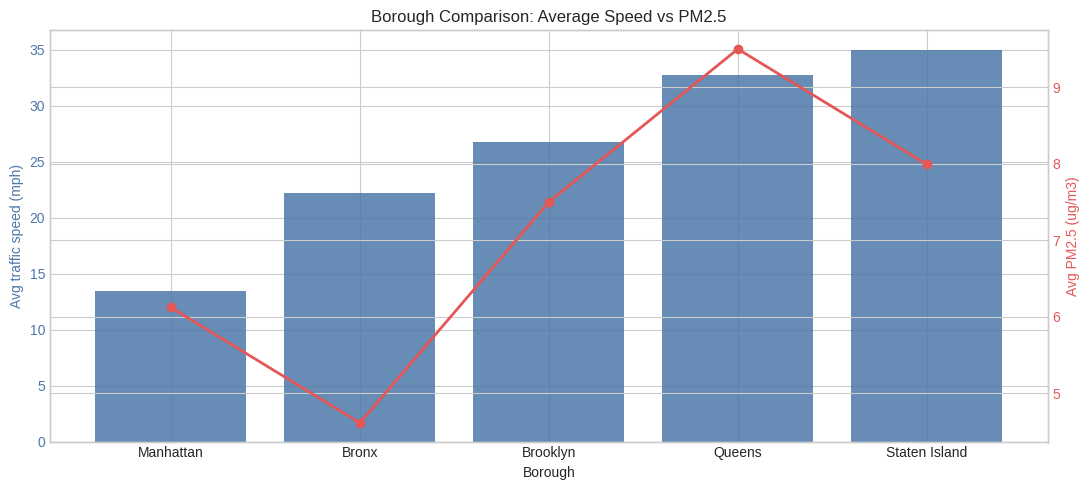

,traffic_borough,total_records,avg_speed_mph,avg_pm25
0,Manhattan,7069609,13.43,6.12
1,Bronx,3228342,22.17,4.61
2,Brooklyn,2018443,26.74,7.50
3,Queens,2014305,32.72,9.50
4,Staten Island,606636,35.00,7.99


In [22]:
# Chart 1: Borough-level speed vs PM2.5 (dual axis)
borough_df = sql_to_pandas("""
SELECT
  traffic_borough,
  COUNT(*) AS total_records,
  ROUND(AVG(traffic_speed), 2) AS avg_speed_mph,
  ROUND(AVG(aq_pm25_ugm3), 2) AS avg_pm25
FROM local.db.enriched_traffic
WHERE aq_pm25_ugm3 IS NOT NULL
GROUP BY traffic_borough
ORDER BY avg_speed_mph ASC
""")

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(borough_df["traffic_borough"], borough_df["avg_speed_mph"], color="#4C78A8", alpha=0.85)
ax1.set_ylabel("Avg traffic speed (mph)", color="#4C78A8")
ax1.tick_params(axis="y", labelcolor="#4C78A8")
ax1.set_xlabel("Borough")
ax1.set_title("Borough Comparison: Average Speed vs PM2.5")

ax2 = ax1.twinx()
ax2.plot(
    borough_df["traffic_borough"],
    borough_df["avg_pm25"],
    color="#E45756",
    marker="o",
    linewidth=2,
)
ax2.set_ylabel("Avg PM2.5 (ug/m3)", color="#E45756")
ax2.tick_params(axis="y", labelcolor="#E45756")

plt.tight_layout()
plt.show()

borough_df

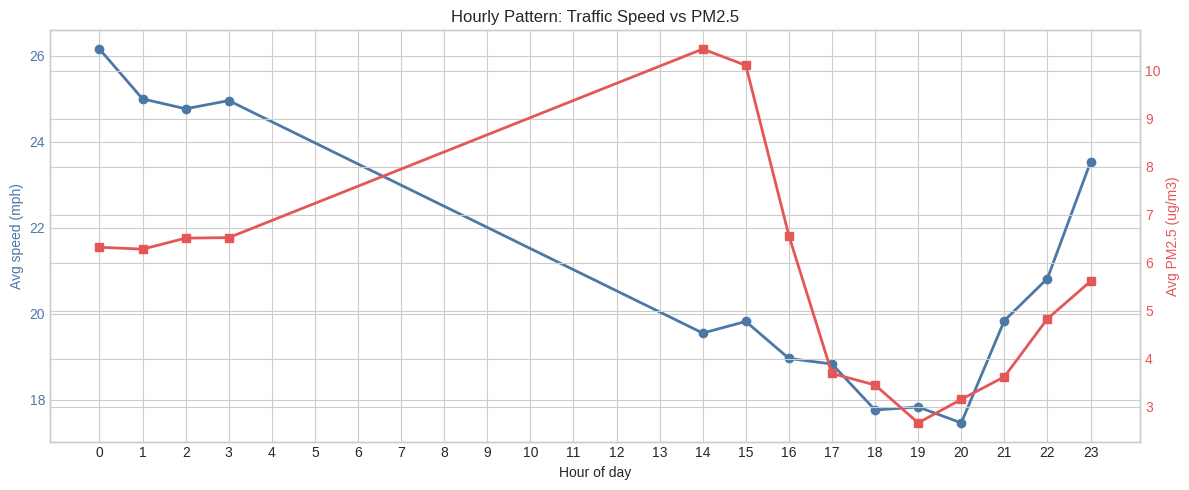

,hour_of_day,avg_speed,avg_pm25,records
0,0,26.16,6.32,672716
1,1,25.00,6.28,765376
2,2,24.77,6.51,1337780
3,3,24.96,6.52,504504
4,14,19.55,10.45,1229495
5,15,19.82,10.11,2961192
6,16,18.96,6.56,1973182
7,17,18.83,3.69,1706968
8,18,17.76,3.45,1070980
9,19,17.83,2.66,1149677


In [23]:
# Chart 2: Hour-of-day trend (speed and PM2.5)
hourly_df = sql_to_pandas("""
SELECT
  HOUR(traffic_event_ts) AS hour_of_day,
  ROUND(AVG(traffic_speed), 2) AS avg_speed,
  ROUND(AVG(aq_pm25_ugm3), 2) AS avg_pm25,
  COUNT(*) AS records
FROM local.db.enriched_traffic
WHERE aq_pm25_ugm3 IS NOT NULL
GROUP BY 1
ORDER BY 1
""")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(hourly_df["hour_of_day"], hourly_df["avg_speed"], marker="o", color="#4C78A8", linewidth=2)
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Avg speed (mph)", color="#4C78A8")
ax1.tick_params(axis="y", labelcolor="#4C78A8")
ax1.set_xticks(range(0, 24, 1))
ax1.set_title("Hourly Pattern: Traffic Speed vs PM2.5")

ax2 = ax1.twinx()
ax2.plot(hourly_df["hour_of_day"], hourly_df["avg_pm25"], marker="s", color="#E45756", linewidth=2)
ax2.set_ylabel("Avg PM2.5 (ug/m3)", color="#E45756")
ax2.tick_params(axis="y", labelcolor="#E45756")

plt.tight_layout()
plt.show()

hourly_df

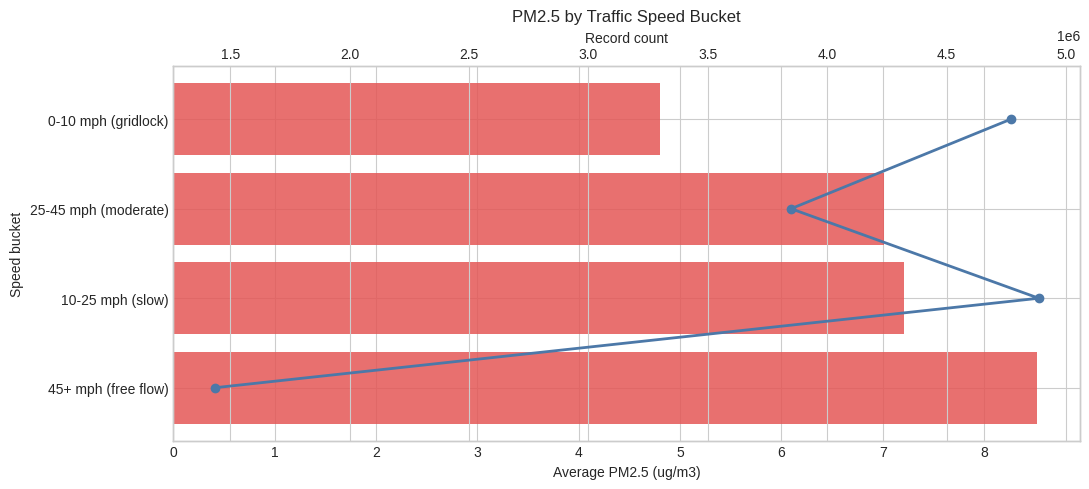

,speed_bucket,records,avg_pm25,stddev_pm25
0,45+ mph (free flow),1434095,8.52,5.68
1,10-25 mph (slow),4885855,7.21,6.68
2,25-45 mph (moderate),3848319,7.01,6.10
3,0-10 mph (gridlock),4769066,4.80,6.20


In [24]:
# Chart 3: Speed bucket pollution profile
speed_bucket_df = sql_to_pandas("""
SELECT
  CASE
    WHEN traffic_speed < 10 THEN '0-10 mph (gridlock)'
    WHEN traffic_speed < 25 THEN '10-25 mph (slow)'
    WHEN traffic_speed < 45 THEN '25-45 mph (moderate)'
    ELSE '45+ mph (free flow)'
  END AS speed_bucket,
  COUNT(*) AS records,
  ROUND(AVG(aq_pm25_ugm3), 2) AS avg_pm25,
  ROUND(STDDEV(aq_pm25_ugm3), 2) AS stddev_pm25
FROM local.db.enriched_traffic
WHERE aq_pm25_ugm3 IS NOT NULL
GROUP BY 1
ORDER BY avg_pm25 DESC
""")

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.barh(speed_bucket_df["speed_bucket"], speed_bucket_df["avg_pm25"], color="#E45756", alpha=0.85)
ax1.set_xlabel("Average PM2.5 (ug/m3)")
ax1.set_ylabel("Speed bucket")
ax1.set_title("PM2.5 by Traffic Speed Bucket")

ax2 = ax1.twiny()
ax2.plot(speed_bucket_df["records"], speed_bucket_df["speed_bucket"], marker="o", color="#4C78A8", linewidth=2)
ax2.set_xlabel("Record count")

plt.tight_layout()
plt.show()

speed_bucket_df

## Advanced Insight Visuals

These additional visuals focus on data reliability, confounder impact, and spatial stability.

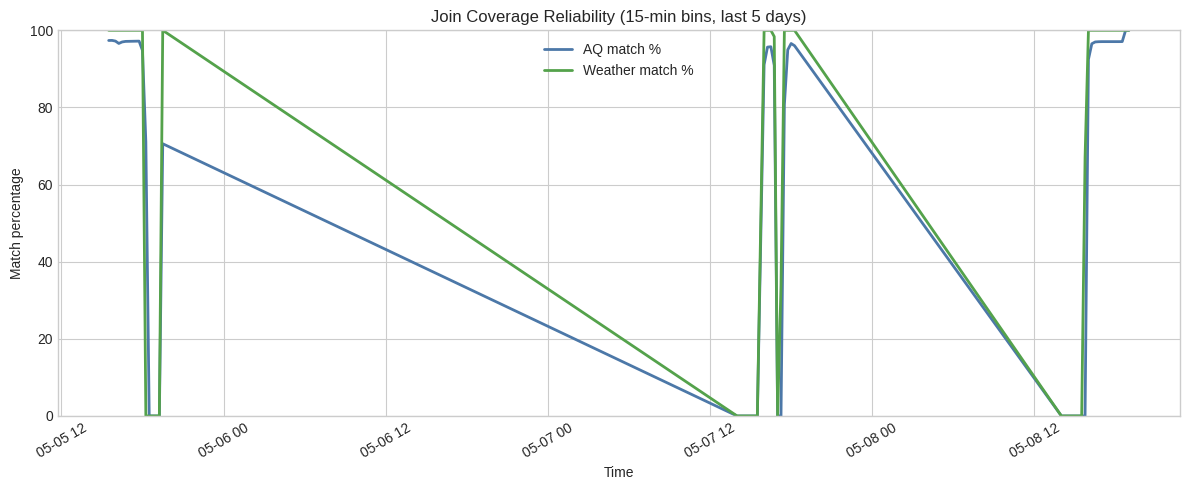

,ts_15m,total_rows,aq_match_pct,weather_match_pct
32,2026-05-08 14:15:00,300,0.00,0.00
33,2026-05-08 14:30:00,300,0.00,0.00
34,2026-05-08 14:45:00,300,0.00,0.00
35,2026-05-08 15:00:00,300,0.00,0.00
36,2026-05-08 15:15:00,300,0.00,0.00
37,2026-05-08 15:30:00,300,0.00,0.00
38,2026-05-08 15:45:00,606,0.00,67.00
39,2026-05-08 16:00:00,28995,92.47,100.00
40,2026-05-08 16:15:00,129403,96.52,100.00
41,2026-05-08 16:30:00,156637,96.99,100.00


In [25]:
# Chart 4: Join coverage trend over time (AQ + weather)
coverage_df = sql_to_pandas("""
SELECT
  to_timestamp(from_unixtime(CAST(FLOOR(unix_timestamp(traffic_event_ts) / 900) * 900 AS BIGINT))) AS ts_15m,
  COUNT(*) AS total_rows,
  ROUND(100.0 * SUM(CASE WHEN aq_pm25_ugm3 IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS aq_match_pct,
  ROUND(100.0 * SUM(CASE WHEN weather_temperature IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS weather_match_pct
FROM local.db.enriched_traffic
WHERE traffic_event_ts >= current_timestamp() - INTERVAL 5 DAYS
GROUP BY 1
ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(coverage_df["ts_15m"], coverage_df["aq_match_pct"], label="AQ match %", color="#4C78A8", linewidth=2)
ax.plot(coverage_df["ts_15m"], coverage_df["weather_match_pct"], label="Weather match %", color="#54A24B", linewidth=2)
ax.set_title("Join Coverage Reliability (15-min bins, last 5 days)")
ax.set_xlabel("Time")
ax.set_ylabel("Match percentage")
ax.set_ylim(0, 100)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

coverage_df.tail(20)

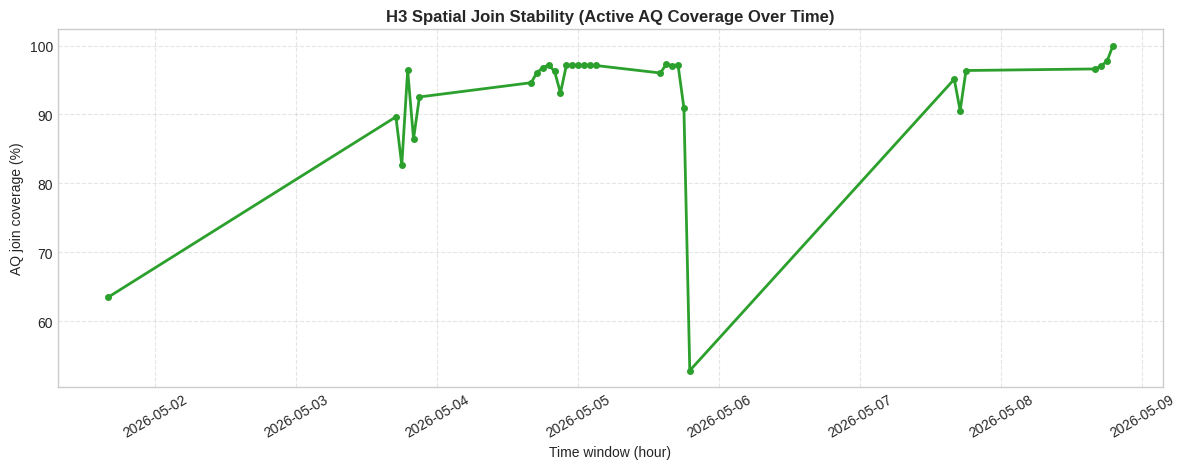

,time_window,aq_join_coverage_percent
0,2026-05-01 16:00:00,63.44
1,2026-05-03 17:00:00,89.65
2,2026-05-03 18:00:00,82.65
3,2026-05-03 19:00:00,96.45
4,2026-05-03 20:00:00,86.44
5,2026-05-03 21:00:00,92.54
6,2026-05-04 16:00:00,94.61
7,2026-05-04 17:00:00,96.07
8,2026-05-04 18:00:00,96.80
9,2026-05-04 19:00:00,97.18


In [26]:
# Chart #5: Hourly AQ join coverage query + visualization (Active Stream Only)
aq_join_coverage_df = sql_to_pandas("""
SELECT
  date_trunc('hour', traffic_event_ts) AS time_window,
  ROUND(100.0 * SUM(CASE WHEN aq_pm25_ugm3 IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS aq_join_coverage_percent
FROM local.db.enriched_traffic
GROUP BY 1
HAVING SUM(CASE WHEN aq_pm25_ugm3 IS NOT NULL THEN 1 ELSE 0 END) > 0
ORDER BY 1 ASC
""")

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(
    aq_join_coverage_df["time_window"],
    aq_join_coverage_df["aq_join_coverage_percent"],
    color="#2ca02c", 
    linewidth=2,
    marker="o",
    markersize=4,
)
ax.set_title("H3 Spatial Join Stability (Active AQ Coverage Over Time)", fontweight='bold')
ax.set_xlabel("Time window (hour)")
ax.set_ylabel("AQ join coverage (%)")

ax.grid(alpha=0.5, linestyle='--')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

aq_join_coverage_df

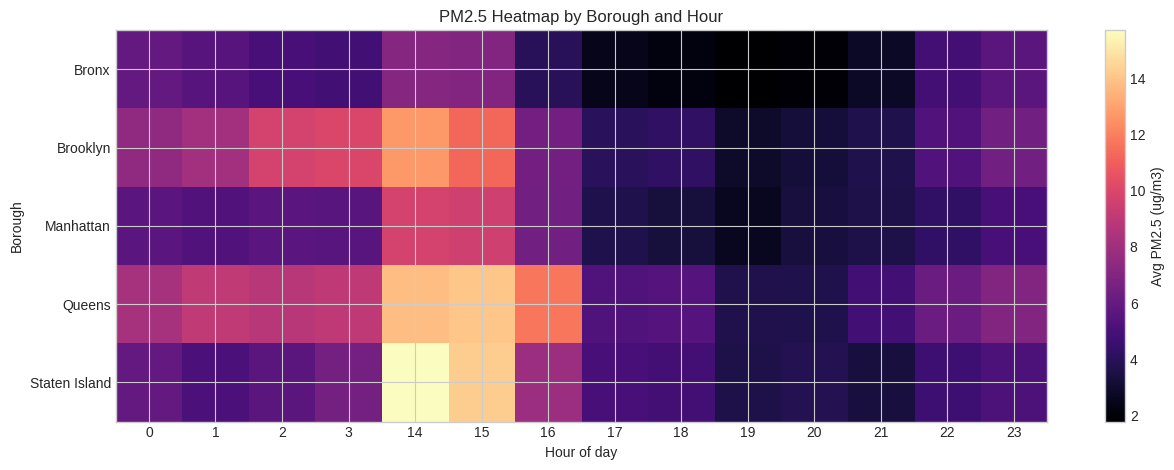

,traffic_borough,hour_of_day,avg_pm25,avg_speed,records
0,Bronx,0,5.95,30.60,137600
1,Bronx,1,5.52,36.04,157444
2,Bronx,2,4.99,35.25,274037
3,Bronx,3,4.82,35.09,103488
4,Bronx,14,7.16,19.60,251831
...,...,...,...,...,...
65,Staten Island,19,3.58,30.22,46062
66,Staten Island,20,3.83,27.27,12804
67,Staten Island,21,3.39,27.20,4536
68,Staten Island,22,4.68,28.01,13752


In [27]:
# Chart 6: Hour x borough heatmap for PM2.5 intensity
borough_hour_df = sql_to_pandas("""
SELECT
  traffic_borough,
  HOUR(traffic_event_ts) AS hour_of_day,
  ROUND(AVG(aq_pm25_ugm3), 2) AS avg_pm25,
  ROUND(AVG(traffic_speed), 2) AS avg_speed,
  COUNT(*) AS records
FROM local.db.enriched_traffic
WHERE aq_pm25_ugm3 IS NOT NULL
GROUP BY 1, 2
ORDER BY 1, 2
""")

pm25_pivot = borough_hour_df.pivot(index="traffic_borough", columns="hour_of_day", values="avg_pm25").fillna(0)

fig, ax = plt.subplots(figsize=(13, 4.8))
im = ax.imshow(pm25_pivot.values, aspect="auto", cmap="magma")
ax.set_title("PM2.5 Heatmap by Borough and Hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Borough")
ax.set_xticks(range(len(pm25_pivot.columns)))
ax.set_xticklabels(pm25_pivot.columns)
ax.set_yticks(range(len(pm25_pivot.index)))
ax.set_yticklabels(pm25_pivot.index)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Avg PM2.5 (ug/m3)")

plt.tight_layout()
plt.show()

# Full borough-hour table (sorted) for inspection/export.
borough_hour_df.sort_values(["traffic_borough", "hour_of_day"]).reset_index(drop=True)

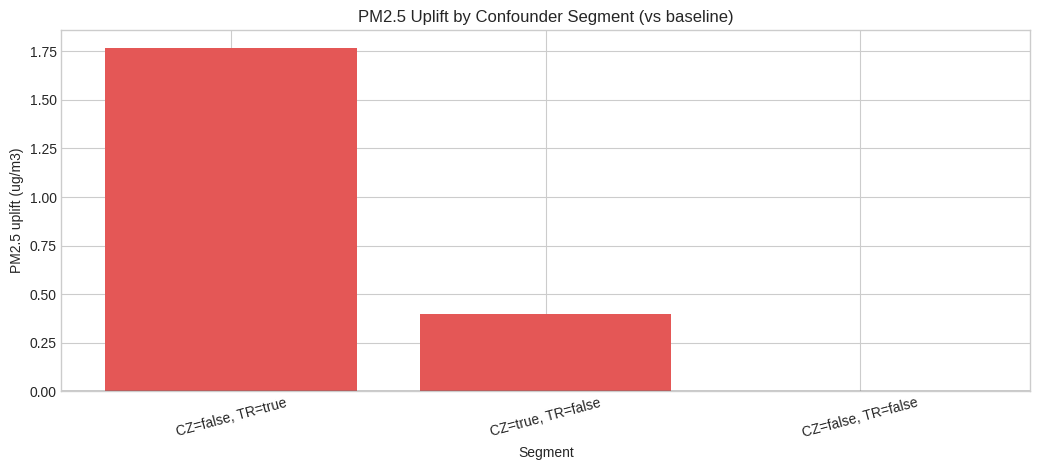

,in_congestion_zone,near_truck_route,records,avg_pm25,pm25_uplift_vs_baseline,segment
0,false,true,11421322,6.93,1.77,"CZ=false, TR=true"
1,true,false,728,5.56,0.40,"CZ=true, TR=false"
2,false,false,3515285,5.16,0.00,"CZ=false, TR=false"


In [28]:
# Chart 7: Confounder uplift vs baseline (non-congestion + non-truck-route)
confounder_df = sql_to_pandas("""
WITH base AS (
  SELECT AVG(aq_pm25_ugm3) AS base_pm25
  FROM local.db.enriched_traffic
  WHERE aq_pm25_ugm3 IS NOT NULL
    AND is_in_congestion_zone = false
    AND is_near_truck_route = false
)
SELECT
  CAST(is_in_congestion_zone AS STRING) AS in_congestion_zone,
  CAST(is_near_truck_route AS STRING) AS near_truck_route,
  COUNT(*) AS records,
  ROUND(AVG(aq_pm25_ugm3), 2) AS avg_pm25,
  ROUND(AVG(aq_pm25_ugm3) - (SELECT base_pm25 FROM base), 2) AS pm25_uplift_vs_baseline
FROM local.db.enriched_traffic
WHERE aq_pm25_ugm3 IS NOT NULL
GROUP BY 1, 2
ORDER BY pm25_uplift_vs_baseline DESC
""")

confounder_df["segment"] = (
    "CZ=" + confounder_df["in_congestion_zone"] + ", TR=" + confounder_df["near_truck_route"]
)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
colors = ["#E45756" if x > 0 else "#54A24B" for x in confounder_df["pm25_uplift_vs_baseline"]]
ax.bar(confounder_df["segment"], confounder_df["pm25_uplift_vs_baseline"], color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("PM2.5 Uplift by Confounder Segment (vs baseline)")
ax.set_xlabel("Segment")
ax.set_ylabel("PM2.5 uplift (ug/m3)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

confounder_df

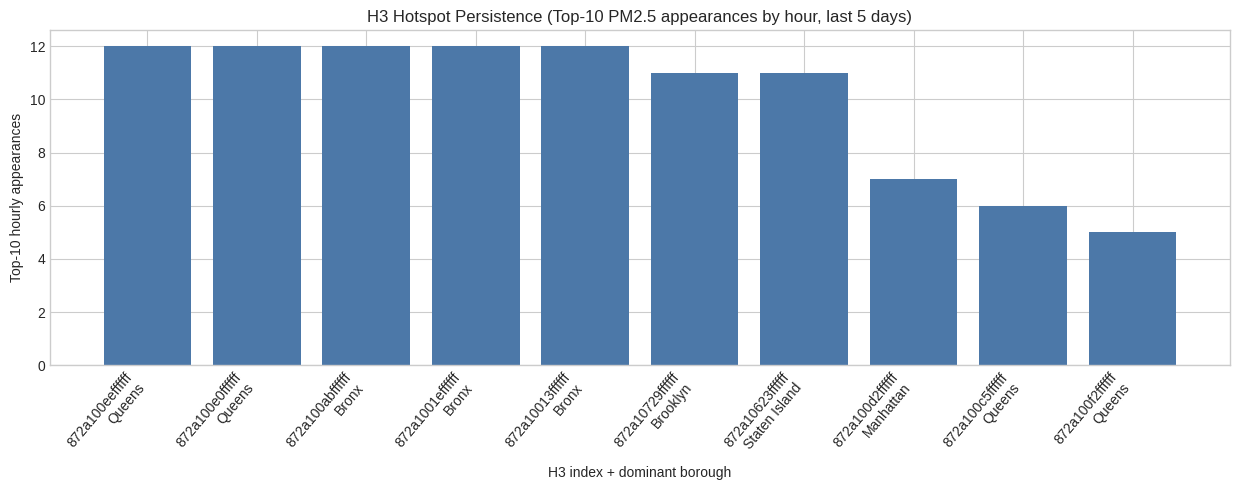

,h3_index,dominant_borough,top10_appearances,mean_pm25_when_top10,dominant_borough_rows
0,872a100eeffffff,Queens,12,11.03,75796
1,872a100e0ffffff,Queens,12,10.50,92784
2,872a100abffffff,Bronx,12,9.99,37898
3,872a1001effffff,Bronx,12,8.22,151152
4,872a10013ffffff,Bronx,12,7.20,151152
5,872a10729ffffff,Brooklyn,11,7.16,680184
6,872a10623ffffff,Staten Island,11,6.94,227388
7,872a100d2ffffff,Manhattan,7,2.75,465020
8,872a100c5ffffff,Queens,6,9.96,37898
9,872a100f2ffffff,Queens,5,17.20,171488


In [29]:
# Chart 8: Top polluted H3 hotspot persistence + H3 -> dominant borough mapping
hotspot_persistence_df = sql_to_pandas("""
WITH base AS (
  SELECT
    date_trunc('hour', traffic_event_ts) AS hour_bin,
    h3_index,
    traffic_borough,
    aq_pm25_ugm3
  FROM local.db.enriched_traffic
  WHERE aq_pm25_ugm3 IS NOT NULL
    AND traffic_event_ts >= current_timestamp() - INTERVAL 5 DAYS
),
hourly_h3 AS (
  SELECT
    hour_bin,
    h3_index,
    ROUND(AVG(aq_pm25_ugm3), 2) AS avg_pm25
  FROM base
  GROUP BY 1, 2
),
ranked AS (
  SELECT
    hour_bin,
    h3_index,
    avg_pm25,
    DENSE_RANK() OVER (PARTITION BY hour_bin ORDER BY avg_pm25 DESC) AS pm25_rank
  FROM hourly_h3
),
hotspot AS (
  SELECT
    h3_index,
    COUNT(*) AS top10_appearances,
    ROUND(AVG(avg_pm25), 2) AS mean_pm25_when_top10
  FROM ranked
  WHERE pm25_rank <= 10
  GROUP BY h3_index
),
borough_counts AS (
  SELECT
    h3_index,
    traffic_borough,
    COUNT(*) AS borough_rows,
    ROW_NUMBER() OVER (
      PARTITION BY h3_index
      ORDER BY COUNT(*) DESC, traffic_borough
    ) AS rn
  FROM base
  GROUP BY h3_index, traffic_borough
),
dominant_borough AS (
  SELECT
    h3_index,
    traffic_borough AS dominant_borough,
    borough_rows
  FROM borough_counts
  WHERE rn = 1
)
SELECT
  h.h3_index,
  d.dominant_borough,
  h.top10_appearances,
  h.mean_pm25_when_top10,
  d.borough_rows AS dominant_borough_rows
FROM hotspot h
LEFT JOIN dominant_borough d
  ON h.h3_index = d.h3_index
ORDER BY h.top10_appearances DESC, h.mean_pm25_when_top10 DESC
LIMIT 10
""")

fig, ax = plt.subplots(figsize=(12.5, 5))
labels = hotspot_persistence_df["h3_index"] + "\n" + hotspot_persistence_df["dominant_borough"].fillna("Unknown")
ax.bar(labels, hotspot_persistence_df["top10_appearances"], color="#4C78A8")
ax.set_title("H3 Hotspot Persistence (Top-10 PM2.5 appearances by hour, last 5 days)")
ax.set_xlabel("H3 index + dominant borough")
ax.set_ylabel("Top-10 hourly appearances")
plt.xticks(rotation=50, ha="right")
plt.tight_layout()
plt.show()

# Includes H3 -> dominant borough mapping for each hotspot row.
hotspot_persistence_df